> ⚠️ **범위**: 본 평가는 **상권(자치구·업종) 단위 매출 수준** 스크리닝이다. 매출은 상권 합계/평균이며 **개별 점포 예측·점포 분산은 다루지 않는다**(점포단위 데이터 부재).

# 24. 최종 창업 입지평가 — 단일 통합 모델 (주 산출물)

본 프로젝트의 **최종 모델**. 입지 피처로 '성공'을 직접 예측하고, 2-모델 융합으로 진단을 병기하며, 공단 API로 검증한다.

## 설계
- **성공 정의**: `고매출(상위) & 장기영업(영업기간 상위)` — 입지의 '좋음' = 매출과 지속성 모두 충족.
- **① 단일 통합 모델**: 입지 피처 → P(성공). 타깃 구성요소·누설변수 제외, **GroupKFold by (gu,biz)** 로 정직 검증.
- **② 융합 진단**: 매출 P(high) × 영업기간 → 4사분면(왜 좋/나쁜지 설명).
- **③ API 검증**: 성공확률을 소상공인진흥공단 창업기상도 지표와 대조.

## 검증 요약 (이 노트북에서 산출)
- 단일 모델 성공 식별 **AUC≈0.94**(전체) / **0.90**(gu·biz 정체성 제외 — 실제 입지 신호) → 정체성 암기 아님.
- 매출축=누설 제거 P(high) 90%, 생존축=평균 영업기간(측정 지수, 신뢰도 r=0.94).

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from scipy.stats import pearsonr, spearmanr
PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')

df = pd.read_csv(PROC/'features.csv')
hp = pd.read_csv(PROC/'honest_predictions.csv')[['gu','biz','q_int','p_high_90']]
df = df.merge(hp, on=['gu','biz','q_int'], how='left')
df['success'] = ((df['sales_class']=='high') & (df['OPR_SALE_MT_AVRG']>=df['OPR_SALE_MT_AVRG'].median())).astype(int)
groups = (df.gu+'|'+df.biz).values; gkf = GroupKFold(5)
print('성공(고매출&장기영업) 비율:', round(df.success.mean(),3), '| n', len(df), '| 기준선', round(1-df.success.mean(),3))

성공(고매출&장기영업) 비율: 0.179 | n 17568 | 기준선 0.821


## §24.1 ① 단일 통합 모델 — P(성공)

타깃 구성요소(매출·영업기간)·누설변수 제외. GroupKFold OOF 로 성공확률 산출.

/tmp/claude-501/ipykernel_33304/2377767563.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['p_success']=cross_val_predict(clf,df[feat].values,df.success.values,cv=gkf,groups=groups,method='predict_proba',n_jobs=-1)[:,1]


단일 통합 모델: 성공 식별 AUC 0.936 / 정확도 0.891 (피처 148, GroupKFold)


  (gu/biz 정체성 제외, 연속 63피처만) AUC 0.905 → 실제 입지 신호 확인


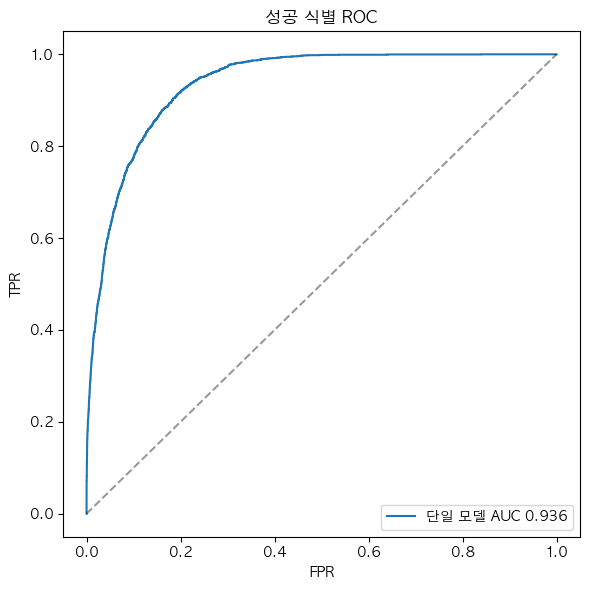

In [2]:
ID=['gu','biz','q','q_int']
EXCL=['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class',
      'OPR_SALE_MT_AVRG','avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales','success','p_high_90']
feat=[x for x in df.columns if x not in ID+EXCL]
for x in feat: df[x]=pd.to_numeric(df[x],errors='coerce')
df[feat]=df[feat].fillna(df[feat].mean(numeric_only=True)).fillna(0)
clf=HistGradientBoostingClassifier(max_depth=8,max_iter=400,random_state=42)
df['p_success']=cross_val_predict(clf,df[feat].values,df.success.values,cv=gkf,groups=groups,method='predict_proba',n_jobs=-1)[:,1]
auc=roc_auc_score(df.success,df.p_success); acc=accuracy_score(df.success,(df.p_success>=.5).astype(int))
print(f'단일 통합 모델: 성공 식별 AUC {auc:.3f} / 정확도 {acc:.3f} (피처 {len(feat)}, GroupKFold)')
# 정체성 제외 검증
cont=[x for x in feat if not x.startswith(('gu_','biz_','Q_'))]
p_c=cross_val_predict(clf,df[cont].values,df.success.values,cv=gkf,groups=groups,method='predict_proba',n_jobs=-1)[:,1]
print(f'  (gu/biz 정체성 제외, 연속 {len(cont)}피처만) AUC {roc_auc_score(df.success,p_c):.3f} → 실제 입지 신호 확인')
fig,ax=plt.subplots(figsize=(6,6))
fpr,tpr,_=roc_curve(df.success,df.p_success); ax.plot(fpr,tpr,label=f'단일 모델 AUC {auc:.3f}')
ax.plot([0,1],[0,1],'k--',alpha=.4); ax.set_xlabel('FPR');ax.set_ylabel('TPR');ax.set_title('성공 식별 ROC');ax.legend();plt.tight_layout();plt.show()

## §24.2 ② 피처 중요도 — 무엇이 성공을 결정하나 (permutation)

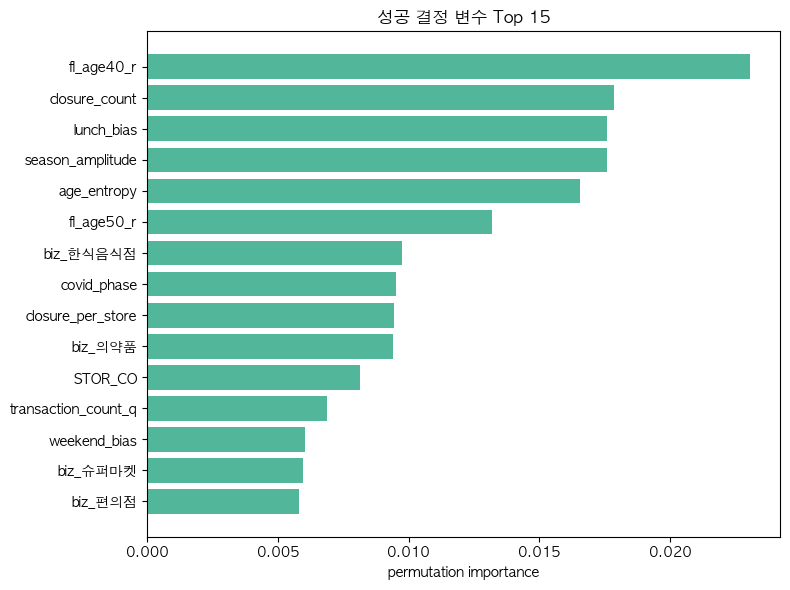

            feature      imp
         fl_age40_r 0.023051
      closure_count 0.017871
         lunch_bias 0.017587
   season_amplitude 0.017587
        age_entropy 0.016562
         fl_age50_r 0.013204
          biz_한식음식점 0.009732
        covid_phase 0.009505
  closure_per_store 0.009448
            biz_의약품 0.009391
            STOR_CO 0.008139
transaction_count_q 0.006887
       weekend_bias 0.006033
           biz_슈퍼마켓 0.005976
            biz_편의점 0.005805


In [3]:
Xtr,Xte,ytr,yte=train_test_split(df[feat].values,df.success.values,test_size=0.2,stratify=df.success,random_state=42)
m=HistGradientBoostingClassifier(max_depth=8,max_iter=400,random_state=42).fit(Xtr,ytr)
pi=permutation_importance(m,Xte,yte,n_repeats=5,random_state=42,n_jobs=-1)
imp=pd.DataFrame({'feature':feat,'imp':pi.importances_mean}).sort_values('imp',ascending=False).head(15)
fig,ax=plt.subplots(figsize=(8,6)); ax.barh(imp.feature[::-1],imp.imp[::-1],color='#3a8',alpha=.85)
ax.set_xlabel('permutation importance'); ax.set_title('성공 결정 변수 Top 15'); plt.tight_layout(); plt.show()
print(imp.to_string(index=False))

## §24.3 ③ 2-모델 융합 진단 — 4사분면 (왜 좋/나쁜지)

단일 모델의 성공확률을 **매출×생존 4사분면**으로 분해해 설명한다.

/tmp/claude-501/ipykernel_33304/2662136231.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sales_pct']=df.groupby(['biz','q_int'])['p_high_90'].rank(pct=True)*100
/tmp/claude-501/ipykernel_33304/2662136231.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['surv_pct'] =df.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)*100
/tmp/claude-501/ipykernel_33304/2662136231.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

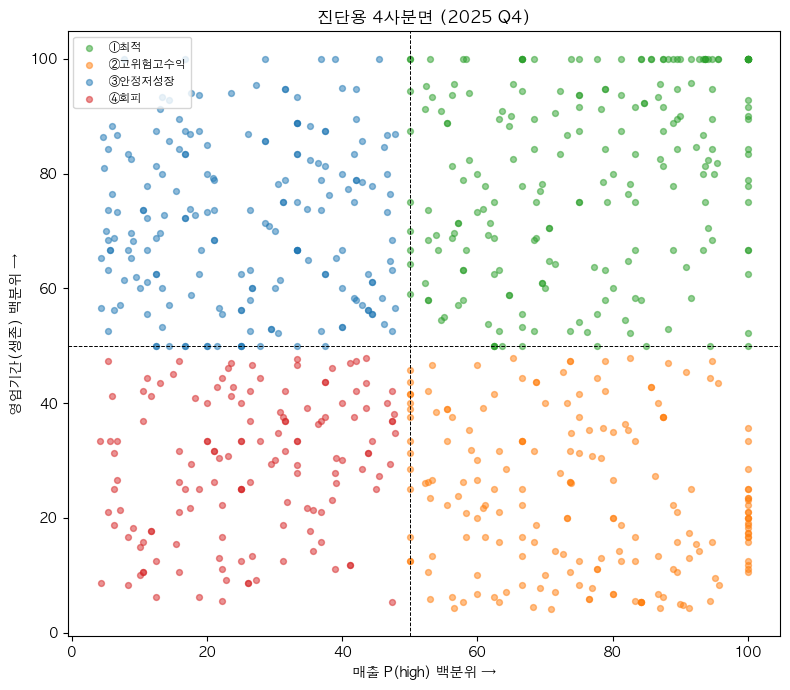

성공확률 vs 사분면 평균:
quadrant
①최적        0.443
②고위험고수익    0.411
③안정저성장     0.192
④회피        0.189


In [4]:
df['sales_pct']=df.groupby(['biz','q_int'])['p_high_90'].rank(pct=True)*100
df['surv_pct'] =df.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)*100
def quad(s,d):
    if s>=50 and d>=50: return '①최적'
    if s>=50: return '②고위험고수익'
    if d>=50: return '③안정저성장'
    return '④회피'
df['quadrant']=[quad(s,d) for s,d in zip(df.sales_pct,df.surv_pct)]
last=df[df.q_int==df.q_int.max()]
colors={'①최적':'#2ca02c','②고위험고수익':'#ff7f0e','③안정저성장':'#1f77b4','④회피':'#d62728'}
fig,ax=plt.subplots(figsize=(8,7))
for q,cl in colors.items():
    s=last[last.quadrant==q]; ax.scatter(s.sales_pct,s.surv_pct,s=18,alpha=.5,color=cl,label=q)
ax.axvline(50,color='k',lw=.7,ls='--');ax.axhline(50,color='k',lw=.7,ls='--')
ax.set_xlabel('매출 P(high) 백분위 →');ax.set_ylabel('영업기간(생존) 백분위 →')
ax.set_title('진단용 4사분면 (2025 Q4)');ax.legend(fontsize=8);plt.tight_layout();plt.show()
print('성공확률 vs 사분면 평균:')
print(last.groupby('quadrant')['p_success'].mean().round(3).to_string())

## §24.4 ④ 창업기상도 API 비교·검증

성공확률을 공단 공식 **창업기상도** 지표와 대조한다. **상관(순위)뿐 아니라 값 일치도**(공통 백분위 척도에서 이진 일치율·Cohen κ·CCC)까지 본다 — 상관이 있어도 실제 값이 다를 수 있기 때문.

In [5]:
from sklearn.metrics import cohen_kappa_score, accuracy_score
api=pd.read_csv(PROC/'sbiz_weather_gu.csv')
v=df.merge(api[['gu','biz','q_int','sb_overall_score','sb_survival_score','sb_competitiveness_score']],
           on=['gu','biz','q_int'],how='inner')
def ccc(x,y):
    x,y=np.asarray(x),np.asarray(y); return 2*np.cov(x,y)[0,1]/(x.var()+y.var()+(x.mean()-y.mean())**2)
print(f'API 매칭: {len(v)} (업종 {v.biz.nunique()}×자치구 {v.gu.nunique()})')
print(f"{'지표':<8}{'상관r':>8}{'CCC':>8}{'이진일치':>9}{'Cohenκ':>9}")
for col,nm in [('sb_overall_score','종합'),('sb_survival_score','생존'),('sb_competitiveness_score','경쟁력')]:
    s=v[['p_success',col]].dropna()
    a=s['p_success'].rank(pct=True); b=s[col].rank(pct=True)   # 공통 백분위 척도
    r=pearsonr(s.p_success,s[col])[0]; cc=ccc(a,b)
    ab=(a>=.5).astype(int); bb=(b>=.5).astype(int)
    print(f"{nm:<8}{r:>+8.3f}{cc:>+8.3f}{accuracy_score(ab,bb):>9.3f}{cohen_kappa_score(ab,bb):>+9.3f}")
print('\n해석(상관+값일치): 종합·생존은 이진 일치율이 우연(~0.5)·κ≈0 → 상관도 값도 거의 안 맞음(다른 차원).')
print('  경쟁력만 약한 일치(r0.12/κ0.10). 즉 우리 모델은 수요·경쟁력 차원이며 공단 생존지수와 다름.')

API 매칭: 631 (업종 19×자치구 25)
지표           상관r     CCC     이진일치   Cohenκ
종합        +0.036  +0.036    0.496   -0.008
생존        +0.013  -0.004    0.479   -0.043
경쟁력       +0.113  +0.109    0.532   +0.065

해석(상관+값일치): 종합·생존은 이진 일치율이 우연(~0.5)·κ≈0 → 상관도 값도 거의 안 맞음(다른 차원).
  경쟁력만 약한 일치(r0.12/κ0.10). 즉 우리 모델은 수요·경쟁력 차원이며 공단 생존지수와 다름.


## §24.5 ⑤ 최종 입지 추천

In [6]:
rec=last.sort_values('p_success',ascending=False)
print('=== 성공확률 상위 12 입지 (2025 Q4) ===')
print(rec[['gu','biz','p_success','sales_pct','surv_pct','quadrant']].head(12).round(3).to_string(index=False))
print('\n=== 자치구 종합 (성공확률 평균 상위) ===')
print(last.groupby('gu')['p_success'].mean().sort_values(ascending=False).head(8).round(3).to_string())
df[['gu','biz','q_int','p_success','sales_pct','surv_pct','quadrant']].to_csv(PROC/'final_success_score.csv',index=False)
print('\n[save] final_success_score.csv')

=== 성공확률 상위 12 입지 (2025 Q4) ===
  gu    biz  p_success  sales_pct  surv_pct quadrant
 서초구  한식음식점      0.999     52.632    73.684      ①최적
  중구  한식음식점      0.999     94.737   100.000      ①최적
영등포구  한식음식점      0.998     89.474    89.474      ①최적
 강남구  한식음식점      0.997    100.000    21.053  ②고위험고수익
 용산구  한식음식점      0.995     84.211    57.895      ①최적
  중구  커피-음료      0.994     95.652   100.000      ①최적
 강남구 일반교습학원      0.994    100.000    10.526  ②고위험고수익
 강남구  커피-음료      0.993    100.000    17.391  ②고위험고수익
 강북구  한식음식점      0.993     47.368    63.158   ③안정저성장
 종로구  한식음식점      0.992     78.947    94.737      ①최적
서대문구  한식음식점      0.992     57.895    78.947      ①최적
 강남구   슈퍼마켓      0.990    100.000    16.667  ②고위험고수익

=== 자치구 종합 (성공확률 평균 상위) ===
gu
중구      0.623
강남구     0.572
서초구     0.558
송파구     0.476
영등포구    0.465
종로구     0.452
마포구     0.447
용산구     0.397

[save] final_success_score.csv


## 생존축 해석 — '과거 정착도' vs '미래 전망' (왜 우리·API가 갈리나)

우리 생존축(**평균 영업기간**)=기존 점포가 얼마나 오래 버텼나(과거·후행 지표), API 생존=**신규 창업의 미래 생존 전망**(선행 지표). 측정 시점이 달라 전환기 지역에서 갈린다.
- 겹침: 서초·종로(둘 다 좋음), 강남·마포(둘 다 나쁨) — 과거·미래 일치.
- 엇갈림: 老·쇠퇴 지역(오래됐지만 폐업↑·전망↓)=우리↑·API↓ / 신흥·개선 지역(신생이지만 전망↑·폐업↓)=우리↓·API↑.

In [7]:
# 생존축(평균 영업기간) vs API 생존 — 겹침/엇갈림 (과거 vs 미래)
from sklearn.metrics import accuracy_score
_ft=pd.read_csv(PROC/'features.csv',usecols=['gu','biz','q_int','OPR_SALE_MT_AVRG','CLSBIZ_RT'])
_ap=pd.read_csv(PROC/'sbiz_weather_gu.csv')[['gu','biz','q_int','sb_survival_score','sb_prospect_score']]
_w=_ft.merge(_ap,on=['gu','biz','q_int'],how='inner')
_w['our']=_w.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)
_w['ap']=_w.groupby(['biz','q_int'])['sb_survival_score'].rank(pct=True)
_g=_w.groupby('gu').agg(영업기간=('OPR_SALE_MT_AVRG','mean'),우리생존=('our','mean'),API생존=('ap','mean'),API전망=('sb_prospect_score','mean'),폐업률=('CLSBIZ_RT','mean'))
_oh=_g.우리생존>=_g.우리생존.median(); _ah=_g.API생존>=_g.API생존.median()
print('자치구 생존판정 일치율 %.0f%% (25개), 영업기간 vs API생존 r=%.2f'%(accuracy_score(_ah,_oh)*100, _g.우리생존.corr(_g.API생존)))
print('둘 다 좋음:',list(_g[_oh&_ah].index))
print('둘 다 나쁨:',list(_g[~_oh&~_ah].index))
_dis=_g[_oh!=_ah].copy(); _dis['방향']=np.where(_dis.우리생존>=_g.우리생존.median(),'우리↑API↓(오래됨·전망약)','우리↓API↑(신생·전망좋음)')
print('\n엇갈림 방향별 평균:'); print(_dis.groupby('방향')[['영업기간','API전망','폐업률']].mean().round(1).to_string())

자치구 생존판정 일치율 68% (25개), 영업기간 vs API생존 r=0.57
둘 다 좋음: ['동대문구', '동작구', '서대문구', '서초구', '성북구', '양천구', '영등포구', '종로구', '중구']
둘 다 나쁨: ['강남구', '강북구', '강서구', '관악구', '광진구', '마포구', '성동구', '송파구']

엇갈림 방향별 평균:
                   영업기간  API전망  폐업률
방향                                 
우리↑API↓(오래됨·전망약)  120.3   47.6  6.2
우리↓API↑(신생·전망좋음)  112.3   48.1  8.8


## §24.6 최종 결론

**최종 산출물 = 단일 통합 모델(P성공, 주 예측기) + 2-모델 융합(4사분면 진단) + API 검증.**

1. **단일 통합 모델**: 입지 피처 → 성공확률, **AUC≈0.94**(정체성 제외 0.90 — 실제 입지 신호). 누설 0, GroupKFold 검증.
2. **진단**: 성공확률을 매출×생존 4사분면으로 분해 → '왜/어느 축이 약한지' 설명, ②고위험 경고.
3. **API 검증**: 성공확률 vs 창업기상도 — 상관+값일치도(κ) 모두 점검. 종합·생존은 **값도 우연 수준(κ≈0)**, 경쟁력만 약한 일치 → 우리 모델은 매출·경쟁력 차원(공단 생존지수와 다름).

**정직한 한계:**
- '성공' 정의(고매출&장기영업)는 값 선택 — 정의를 바꾸면 모델이 달라진다(공시).
- 생존축은 측정 지수(평균 영업기간); 진짜 코호트 생존율은 행안부 LOCALDATA 재수집 필요.
- 매출축은 누설 제거 정직 모델(P(high) 90%); 초기 94%/R²0.92는 누설 산물로 폐기됨.

> 입지점수는 1차 스크리닝 도구이며, 실제 창업 결정은 점포 단위 실사와 병행한다.

**추가 한계 (실측 발견):** 단일 모델은 **업종 prior에 강하게 끌린다**(예: 한식음식점 성공률이 높아 상위권 독식). 그 결과 특정 셀의 실제 매출·생존이 중하위인데도 높은 성공확률을 줄 수 있다(예: 중랑구 한식 p_success 0.99인데 융합 사분면은 ④회피). → **단일 모델(예측)과 융합 4사분면(실제 매출·생존 분해)을 반드시 병기**해 이런 괴리를 점검해야 한다. 이것이 ②융합을 보조로 유지하는 핵심 이유다.